In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz


# 🎓 THESIS PROJECT: VISUAL ANOMALY DETECTION
## NOTEBOOK 1: BASELINE MODEL & BENCHMARKING

**OBJECTIVE:**
The primary goal of this notebook is to establish a rigorous **Performance Baseline** for Anomaly Detection on the MVTec AD dataset. We aim to conduct a comparative analysis between traditional Machine Learning techniques and a fundamental Deep Learning approach. This comparison serves to scientifically justify the necessity for the complex architectures developed in subsequent notebooks.

**METHODOLOGY:**

1.  **Classic Approach (The Control Group):**

    * Implementation of **Principal Component Analysis (PCA)** for dimensionality reduction, followed by a **One-Class SVM**. This represents the traditional statistical approach to outlier detection.<br><b><br>
    
2.  **Deep Learning Approach (The Experimental Group):**

    * Construction of a **Simple Convolutional Autoencoder (CAE)**. We utilize a shallow architecture to test the basic capability of neural networks to reconstruct "normal" patterns without advanced optimizations.<br><b><br>
    
3.  **Evaluation Strategy:**

    * We utilize the **Area Under the Curve (AUC)** metric to quantitatively measure the success of both methods in differentiating between "Good" (Normal) and "Defective" (Anomalous) samples.

**EXPECTED OUTCOME:**
* A foundational understanding of the dataset's complexity.
* A quantitative **"Performance Floor"** (Baseline AUC). Future models in this thesis must exceed this score to be considered successful improvements.

### BLOCK 1: IMPORT LIBRARIES & HYBRID ENVIRONMENT SETUP

**OBJECTIVE:**
This block initializes a **Hybrid Computational Environment**. Unlike standard notebooks that focus on a single framework, this module imports dependencies for two distinct paradigms: **Classical Machine Learning (Scikit-Learn)** and **Deep Learning (TensorFlow/Keras)**. This dual setup is essential for the thesis's core objective: benchmarking the traditional One-Class SVM algorithm against a modern Convolutional Autoencoder.

**KEY LIBRARIES & DEPENDENCIES:**

* **Classical ML (`sklearn`):**
  
    * **OneClassSVM:** The baseline unsupervised algorithm used for comparison.
    * **PCA (Principal Component Analysis):** A critical pre-processing tool. It performs **Dimensionality Reduction**, compressing high-resolution images into smaller feature vectors so the SVM can process them efficiently without "Curse of Dimensionality" issues.
    * **Metrics (`roc_auc_score`):** Used to mathematically evaluate the detection performance of both models.<br><br>

* **Deep Learning (`tensorflow.keras`):**

    * **Layers (`Conv2D`, `MaxPooling2D`, `UpSampling2D`):** The specific building blocks required to construct the Encoder-Decoder architecture of the Convolutional Autoencoder.<br><br>

* **System & Data (`numpy`, `pandas`, `os`, `tarfile`):** Standard tools for matrix manipulation, file handling, and dataset extraction.

**REPRODUCIBILITY CONFIGURATION:**

* **`np.random.seed(42)` / `tf.random.set_seed(42)`:**

    * We enforce **Determinism** by locking the random number generators. This ensures that weight initialization and data shuffling are identical in every run, making the scientific results reproducible and verifiable.

**GLOBAL PARAMETERS:**

* **`IMG_SIZE = (128, 128)`:** Consistent resolution across all experiments to ensure fair comparison.
* **`TARGET_CLASS = 'bottle'`:** The specific industrial object selected for this benchmark study.

In [5]:
# ==========================================================================================================================================================
# BLOCK 1: IMPORT LIBRARIES AND SETUP ENVIRONMENT
# ==========================================================================================================================================================
# Description: Imports dependencies for SVM and Autoencoder models, sets random seeds,
# and defines global image parameters
# ==========================================================================================================================================================

print("INITIALIZING SYSTEM ENVIRONMENT & LOADING LIBRARIES...\n")
print("Action: Setting up dependencies, global parameters & random seeds.")
print()


# DATA MANIPULATION & VISUALIZATION
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# STANDARD SYSTEM LIBRARIES
import os
import tarfile


# CLASSICAL MACHINE LEARNING LIBRARIES (SCIKIT-LEARN)
# 1. OneClassSVM: The benchmark algorithm used to compare against Deep Learning
# 2. PCA: Used for "Dimensionality Reduction" to compress image data before training
#    (This helps the SVM handle the large number of image pixels efficiently)
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve


# DEEP LEARNING LIBRARIES (TENSORFLOW/KERAS)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D


# REPRODUCIBILITY SETUP
# Set random seeds to ensure reproducible results every time we run the code
np.random.seed(42)
tf.random.set_seed(42)


# GLOBAL PARAMETERS
# Define the global parameters for our images and the specific object we want to analyze
# IMG_SIZE: Resizing images to 128x128 for computational efficiency
# TARGET_CLASS: The specific category we are analyzing (e.g., 'bottle')
# (We chose this class to demonstrate the initial difficulty of detecting subtle defects like contamination)
IMG_SIZE = (128, 128)
TARGET_CLASS = 'bottle'


# FINAL VERIFICATION
print("\n✅ BLOCK 1 COMPLETED: Libraries loaded and environment set up.")

INITIALIZING SYSTEM ENVIRONMENT & LOADING LIBRARIES...

Action: Setting up dependencies, global parameters & random seeds.


✅ BLOCK 1 COMPLETED: Libraries loaded and environment set up.


### BLOCK 2: DATA EXTRACTION & SETUP

**OBJECTIVE:**
This block manages the **Data Staging** phase. Since the MVTec AD dataset is provided in a compressed `.tar.xz` format within Kaggle's "Read-Only" input repository, it is technically impossible to process the files directly. We must migrate the data to the ephemeral "Writeable" working directory (`/kaggle/working/`) to enable image loading and manipulation.

**OPERATIONAL LOGIC:**
The script implements an optimized extraction pipeline:

1.  **Path Configuration:**
    * Establishes strict pointers for the **Source** (Immutable Archive) and **Destination** (Working Workspace).<br><br>
    
2.  **Latency Reduction (Conditional Logic):**
    * Before extracting, the code verifies if the dataset folder already exists (`os.path.exists`).
    * **Significance:** If the environment is persistent or restarted, this check skips the time-consuming unzipping process, allowing immediate focus on model training.<br><br>

3.  **Extraction Protocol:**
    * Utilizes the `tarfile` library to programmatically unpack the dataset only when necessary, ensuring a clean and ready-to-use directory structure.

In [6]:
# ==========================================================================================================================================================
# BLOCK 2: DATA EXTRACTION & SETUP
# ==========================================================================================================================================================
# Description: Handles the extraction of the dataset from the read-only input directory
# to the writeable working directory to enable image processing
# ==========================================================================================================================================================

# CONFIGURATION: PATHS SETUP
# dataset_path: The absolute path to the compressed dataset (Read-Only)
dataset_path = '/kaggle/input/mvtec-ad-dataset/mvtec_anomaly_detection.tar.xz'

# working_dir: The directory where we have write permissions
working_dir = '/kaggle/working/mvtec_anomaly_detection'


# EXECUTION: EXTRACTION LOGIC
# Optimization: Check if the folder exists to avoid re-extracting every time we run the notebook
if not os.path.exists(working_dir) and not os.path.exists(f'/kaggle/working/{TARGET_CLASS}'):
    print("Extracting dataset... Please wait.\n")
    # Open and extract the tar file
    with tarfile.open(dataset_path, 'r:*') as tar:
        tar.extractall('/kaggle/working/')
    print("Dataset extracted successfully.\n")
else:
    # If data exists skip extraction to save time
    print("Dataset is already extracted. Moving on.\n")


# FINAL VERIFICATION
# 1. Visual Check: Print contents of the working directory
print(f"Working Directory Contents: {os.listdir('/kaggle/working/')}\n")

# 2. Logic Check: Verify specifically that the target class folder exists
if os.path.exists(f'/kaggle/working/{TARGET_CLASS}'):
     print(f"✅ BLOCK 2 COMPLETED: Success! Class '{TARGET_CLASS}' is ready.")
else:
     print(f"BLOCK 2 ERROR: Class '{TARGET_CLASS}' failed to extract.")

Dataset is already extracted. Moving on.

Working Directory Contents: ['hazelnut', '.virtual_documents', 'pill', 'leather', 'carpet', 'capsule', 'license.txt', 'zipper', 'grid', 'toothbrush', 'screw', 'cable', 'bottle', 'wood', 'metal_nut', 'tile', 'readme.txt', 'transistor']

✅ BLOCK 2 COMPLETED: Success! Class 'bottle' is ready.


### BLOCK 3: DATA LOADING & PREPROCESSING

**OBJECTIVE:**
This block establishes the **Data Ingestion Pipeline**. A defining characteristic of this Unsupervised Anomaly Detection study is the strict separation of data based on class ("Normality Learning"):
* **Training Set:** Populated *exclusively* with "Good" (non-defective) images. The models must learn the statistical manifold of "normality" without ever seeing a defect.
* **Test Set:** Contains a mixture of "Good" images and various "Defective" categories (e.g., contamination, broken parts). This is used to evaluate the model's ability to flag unknown deviations.

**PREPROCESSING PIPELINE (The `load_images` Function):**
We implement a unified function to ensure consistency between training and inference:

1.  **Geometric Normalization (Resizing):**
    * Adapts all raw inputs to the target dimensions (`128x128`) defined in Block 1.<br><br>

2.  **Array Conversion:**
    * Transcodes image files into numerical matrices suitable for matrix multiplication.<br><br>
    
3.  **Numerical Normalization (Feature Scaling):**
    * Scales pixel intensities from the integer range `[0, 255]` to the floating-point range `[0.0, 1.0]`.
    * **Scientific Rationale:**
  
        * **For Deep Learning:** Crucial for the stability of the Gradient Descent optimizer and faster convergence.
        * **For PCA/SVM:** Essential for distance-based algorithms. Without scaling, high pixel values would dominate the variance calculations, leading to biased and inaccurate results.

In [7]:
# ==========================================================================================================================================================
# BLOCK 3: DATA LOADING AND PREPROCESSING
# ==========================================================================================================================================================
# Description: Loads training and test images, applies resizing, and normalizes pixel values
# ==========================================================================================================================================================

print("EXECUTING DATA LOADING & PREPROCESSING PIPELINE...\n")
print("Action: Loading images, resizing to target shape & normalizing pixel values.\n")
print()

# PATH CONFIGURATION
# Dynamically determine the correct path where data was extracted
if os.path.exists('/kaggle/working/mvtec_anomaly_detection'):
    BASE_DIR = f'/kaggle/working/mvtec_anomaly_detection/{TARGET_CLASS}'
else:
    BASE_DIR = f'/kaggle/working/{TARGET_CLASS}'

print(f"Searching for data in: {BASE_DIR}\n")


# HELPER FUNCTION DEFINITION
def load_images(folder_path):
    
    """
    Iterates through a directory, loads images, resizes, and normalizes them.

    Args:
        folder_path (str): Path to the directory containing images.

    Returns:
        numpy.ndarray: Array of preprocessed images with values scaled to [0, 1].
                       Returns an empty array if the path does not exist.
    """

    images = []

    
    # VALIDATION
    if not os.path.exists(folder_path):
        return np.array([])

    
    # ITERATION & PROCESSING
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)

        if os.path.isfile(img_path) and filename.endswith('.png'):
            # LOADING & RESIZING
            # Load image, resize to global IMG_SIZE, and ensure RGB mode
            img = load_img(img_path, target_size=IMG_SIZE, color_mode='rgb')
            img = img_to_array(img)

            # NORMALIZATION
            # Normalize pixel values from [0, 255] to [0, 1] for better model convergence
            img = img / 255.0
            images.append(img)
            
    return np.array(images)

print(f"Loading data for class: {TARGET_CLASS}...\n")


# 1. LOAD TRAINING IMAGES (NORMAL DATA ONLY)
# Only 'good' samples are available for training in Anomaly Detection tasks
train_images = load_images(f'{BASE_DIR}/train/good')

# 2. LOAD 'GOOD' TEST IMAGES
# Used to calculate False Positive Rate
test_good = load_images(f'{BASE_DIR}/test/good')

# 3. LOAD 'DEFECTIVE' (ANOMALOUS) TEST IMAGES
test_bad = []
test_dir = f'{BASE_DIR}/test'


# ITERATE THROUGH DEFECT SUBFOLDERS
# Loop through subdirectories (e.g., broken, contamination) excluding 'good'
if os.path.exists(test_dir):
    for subdir in os.listdir(test_dir):
        if subdir != 'good': 
            imgs = load_images(os.path.join(test_dir, subdir))
            
            if len(imgs) > 0:
                if len(test_bad) == 0:
                    test_bad = imgs
                else:
                    # Concatenate all defect types into one single array
                    test_bad = np.concatenate((test_bad, imgs))
else:
    print(f"❌ ERROR: Test directory not found at {test_dir}")


# FINAL VERIFICATION
print(f"Train Images (Good): {train_images.shape}")
print(f"Test  Images (Good): {test_good.shape}")
print(f"Test  Images (Bad):  {len(test_bad)}")
print("\n\n✅ BLOCK 3 COMPLETED: Data loaded successfully.")

EXECUTING DATA LOADING & PREPROCESSING PIPELINE...

Action: Loading images, resizing to target shape & normalizing pixel values.


Searching for data in: /kaggle/working/bottle

Loading data for class: bottle...

Train Images (Good): (209, 128, 128, 3)
Test  Images (Good): (20, 128, 128, 3)
Test  Images (Bad):  63


✅ BLOCK 3 COMPLETED: Data loaded successfully.


### BLOCK 4: EXPLORATORY DATA ANALYSIS (EDA)

**OBJECTIVE:**
This block conducts the **Initial Data Profiling**. Before initiating any training procedure, it is mandatory to perform a qualitative verification of the dataset. This step confirms that the "Normal" class is consistent and that the "Anomalous" samples contain perceptible deviations, establishing the baseline difficulty of the detection task.

**VISUALIZATION STRATEGY:**
1.  **Comparative Sample Grid:**
    * **Top Row (Training Set):** Displays random samples of "Good" images to establish the visual baseline of normality.
    * **Bottom Row (Test Set):** Displays random "Defective" samples. This allows for a visual assessment of the anomalies (e.g., scratches, contamination) relative to the good samples.<br><br>

2.  **Statistical Hypothesis Testing (Pixel Intensity Distribution):**
    * We plot the global **Histograms** of pixel intensities for both classes.
    * **Scientific Rationale:** This graph serves as a critical test.<br><br>
        * If the distributions of "Good" and "Bad" images overlap significantly, it proves that the anomalies are **Structural** (texture/shape changes) rather than **Chromatic** (global brightness/color changes).
        * **Conclusion:** This overlap justifies the need for complex algorithms (SVM, Autoencoders) capable of learning spatial patterns, as simple thresholding methods based on color would fail.

INITIATING EXPLORATORY DATA ANALYSIS (EDA)...

Action: Visual inspection of samples & Pixel intensity distribution analysis.




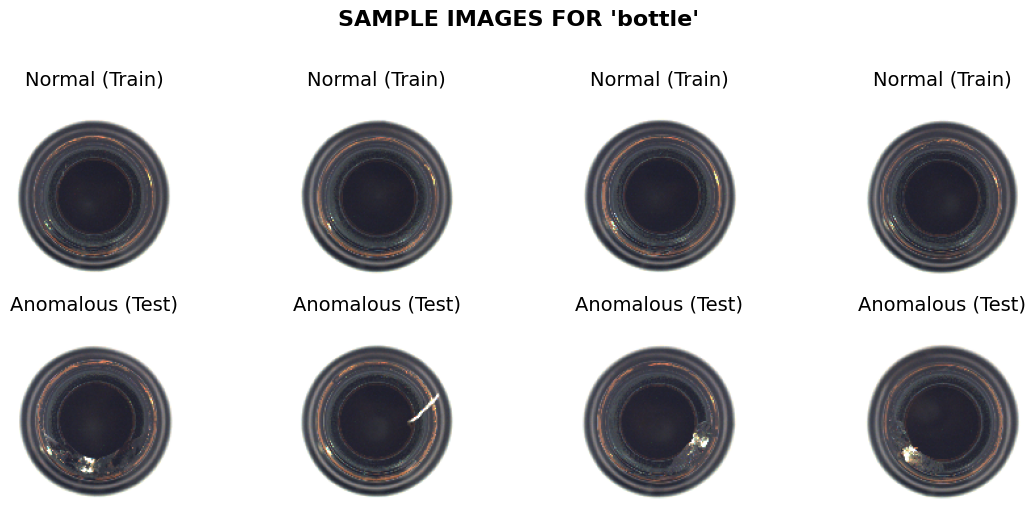

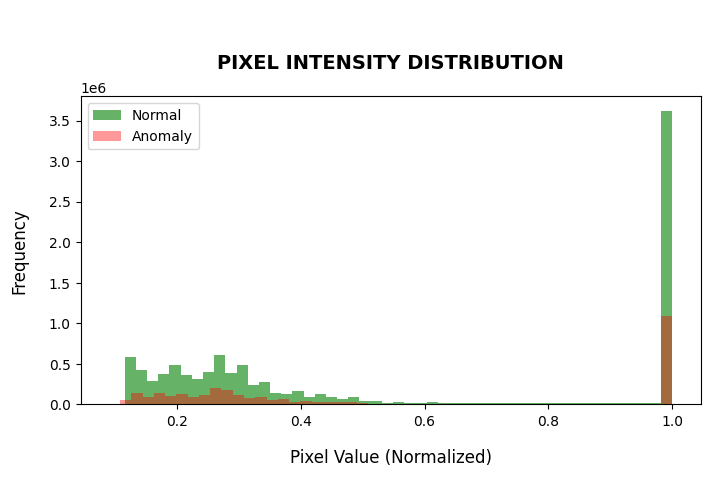



✅ BLOCK 4 COMPLETED: EDA finished.


In [8]:
# ==========================================================================================================================================================
# BLOCK 4: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================================================================================================================
# Description: Visualizes random samples from both categories and analyzes pixel 
# intensity distributions to understand data characteristics
# ==========================================================================================================================================================

print("INITIATING EXPLORATORY DATA ANALYSIS (EDA)...\n")
print("Action: Visual inspection of samples & Pixel intensity distribution analysis.\n")
print()

# 1. SAMPLE VISUALIZATION (NORMAL VS. ANOMALY)
# Visualize random samples from Normal (Train) and Anomalous (Test) sets
n_samples = 4

plt.figure(figsize=(12, 5))
plt.suptitle(f"SAMPLE IMAGES FOR '{TARGET_CLASS}'", fontsize=16, fontweight='bold', y=1.02)
# top=0.88:   Space for the main title
# hspace=0.6: Vertical space between rows (Space ABOVE 'Anomalous')
plt.subplots_adjust(top=0.88, hspace=0.6)

# PLOT NORMAL IMAGES (TRAIN SET)
for i in range(n_samples):
    ax = plt.subplot(2, n_samples, i + 1)
    plt.imshow(train_images[i % len(train_images)])
    plt.title("Normal (Train)", fontsize=14, pad=20)
    plt.axis("off")

# PLOT ANOMALOUS IMAGES (TEST SET)
random_indices = np.random.randint(0, len(test_bad), n_samples)
for i, idx in enumerate(random_indices):
    ax = plt.subplot(2, n_samples, i + 1 + n_samples)
    plt.imshow(test_bad[idx])
    plt.title("Anomalous (Test)", fontsize=14, pad=20)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 2. PIXEL INTENSITY DISTRIBUTION ANALYSIS
# Inspect pixel intensity distribution (Check for obvious statistical differences)
plt.figure(figsize=(8, 4))
plt.hist(train_images.flatten(), bins=50, color='green', alpha=0.6, label='Normal')
plt.hist(test_bad.flatten(), bins=50, color='red', alpha=0.4, label='Anomaly')
plt.title('\n\nPIXEL INTENSITY DISTRIBUTION', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Pixel Value (Normalized)', fontsize=12, labelpad=15)
plt.ylabel('Frequency', fontsize=12, labelpad=15)

plt.legend()
plt.show()


# FINAL VERIFICATION
print("\n\n✅ BLOCK 4 COMPLETED: EDA finished.")

### BLOCK 5: CLASSIC MACHINE LEARNING BENCHMARK (PCA + OCSVM)

**OBJECTIVE:**
This block executes the **Baseline Performance Analysis**. To scientifically validate the effectiveness of Deep Learning (which we will build later), we first establish a benchmark using "Classical" Machine Learning techniques. We combine **Principal Component Analysis (PCA)** with a **One-Class Support Vector Machine (OCSVM)** to detect anomalies without using Neural Networks.

**METHODOLOGICAL PIPELINE:**

1.  **Vectorization (Image Flattening):**
    * Unlike CNNs, classical algorithms (SVMs) cannot process 2D image matrices directly. We transform the `(128, 128)` pixel grids into long 1D feature vectors (`16,384` features per image).<br><br>

2.  **Dimensionality Reduction (PCA):**
    * **The Problem:** Processing 16,384 features directly would lead to the **"Curse of Dimensionality"**, causing the SVM to overfit and run extremely slowly.
    * **The Solution:** We apply PCA with `n_components=0.95`. This mathematically compresses the data, retaining **95% of the information (variance)** while discarding noise and redundant pixels. This drastically reduces the feature space (usually to a few hundred), making the problem computationally tractable.<br><br>

3.  **Boundary Estimation (One-Class SVM):**
    * We train the SVM strictly on the "Normal" data.
    * **Logic:** The algorithm maps the compressed data into a high-dimensional space and attempts to find a hyper-sphere that encloses the "normal" samples. Anything falling outside this boundary during testing is classified as an "Anomaly".<br><br>
    
4.  **Performance Quantificaton (AUC Score):**
    * We evaluate the model using the **Area Under the Curve (AUC)** metric. This single number (0.0 to 1.0) summarizes how well the SVM separates good parts from defective ones.

In [9]:
# ==========================================================================================================================================================
# BLOCK 5: CLASSIC MACHINE LEARNING (PCA + ONE-CLASS SVM)
# ==========================================================================================================================================================
# Description: Trains a benchmark model using PCA for dimensionality reduction and 
# One-Class SVM for anomaly detection, then calculates the AUC score
# ==========================================================================================================================================================

print("INITIATING CLASSICAL ML BENCHMARK PIPELINE...\n")
print("Action: Dimensionality Reduction (PCA) & One-Class SVM Training.\n")
print()


# IMAGE FLATTENING
# SVM requires 2D input (samples, features), not 3D images
x_train_flat = train_images.reshape(train_images.shape[0], -1)
x_test_good_flat = test_good.reshape(test_good.shape[0], -1)
x_test_bad_flat = test_bad.reshape(test_bad.shape[0], -1)


# TEST SET PREPARATION
# Prepare full test set and ground truth labels (0 = Good, 1 = Bad)
x_test_full_flat = np.concatenate((x_test_good_flat, x_test_bad_flat))
y_test_labels = np.concatenate((np.zeros(len(x_test_good_flat)), np.ones(len(x_test_bad_flat))))


# DIMENSIONALITY REDUCTION (PCA - Principal Component Analysis)
# Retain 95% of variance to reduce noise and computational cost
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_flat)
x_test_pca = pca.transform(x_test_full_flat)

print(f"PCA reduced features from {x_train_flat.shape[1]} to {x_train_pca.shape[1]}")


# MODEL TRAINING (ONE-CLASS SVM)
# Learn the boundary of 'normal' data using the reduced features
# nu=0.05 allows for a small percentage of outliers in the training data
svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
svm.fit(x_train_pca)


# EVALUATION & SCORING
preds_raw = svm.predict(x_test_pca)

# SVM outputs: 1 (Normal), -1 (Anomaly). Convert to: 0 (Normal), 1 (Anomaly) for AUC calc
preds_binary = [0 if x == 1 else 1 for x in preds_raw]
auc_svm = roc_auc_score(y_test_labels, preds_binary)


# FINAL VERIFICATION
print(f"\nCLASSIC ML (SVM) RESULT -> AUC SCORE: {auc_svm:.2f}")
print("\n\n✅ BLOCK 5 COMPLETED: Benchmark SVM trained and evaluated.")

INITIATING CLASSICAL ML BENCHMARK PIPELINE...

Action: Dimensionality Reduction (PCA) & One-Class SVM Training.


PCA reduced features from 49152 to 150

CLASSIC ML (SVM) RESULT -> AUC SCORE: 0.57


✅ BLOCK 5 COMPLETED: Benchmark SVM trained and evaluated.


### BLOCK 6: DEFINE BASELINE DEEP LEARNING MODEL (SIMPLE AUTOENCODER)

**OBJECTIVE:**
This block constructs the Deep Learning architecture using the Keras Functional API. We define a **Convolutional Autoencoder (CAE)**, a specialized unsupervised neural network designed to learn efficient data codings.


**ARCHITECTURAL DESIGN (THE "HOURGLASS" TOPOLOGY):**
The model follows a symmetric Encoder-Decoder structure:

1.  **The Encoder (Compression Path):**
    * **Function:** Reduces the spatial dimensions of the input image (`128x128`) to extract high-level abstract features.
    * **Layers:** Uses `Conv2D` for feature detection and `MaxPooling2D` for downsampling. This forces the model to discard noise and retain only the essential structural information.<br><br>
    
2.  **The Bottleneck (Latent Space):**
    * The central point of the network where the image is represented in its most compressed form. The model must learn to describe the object using this limited capacity.<br><br>
    
3.  **The Decoder (Reconstruction Path):**
    * **Function:** Attempts to reconstruct the original image from the compressed bottleneck features.
    * **Layers:** Uses `UpSampling2D` to restore the spatial resolution back to `128x128`.

**COMPILATION STRATEGY:**
* **Loss Function (`mse`):** We use **Mean Squared Error**. The model minimizes the difference between the *Input* (Original) and the *Output* (Reconstruction).
* **Optimizer (`adam`):** An adaptive learning rate algorithm chosen for its efficiency in converging convolutional networks.
* **Output Activation (`sigmoid`):**<br><br>
    * **Critical Choice:** The final layer uses a Sigmoid activation function. This forces the output pixel values to be strictly between **0.0 and 1.0**.
    * **Reasoning:** This matches the data normalization performed in Block 3, ensuring the model's output format is mathematically identical to the input.

In [10]:
# ==========================================================================================================================================================
# BLOCK 6: DEFINE BASELINE DEEP LEARNING MODEL (SIMPLE AUTOENCODER)
# ==========================================================================================================================================================
# Description: Constructs the Convolutional Autoencoder architecture with Encoder (compression)
# and Decoder (reconstruction) segments using the Keras Functional API
# ==========================================================================================================================================================

print("CONSTRUCTING BASELINE DEEP LEARNING ARCHITECTURE...\n")
print("Action: Defining Convolutional Autoencoder (Encoder-Decoder Network).")
print()


# INPUT SPECIFICATION
# Define input shape (128x128 pixels, 3 channels)
input_img = Input(shape=(128, 128, 3))


# ENCODER (COMPRESSION)
# We use a simple architecture without BatchNormalization or Dropout to establish a baseline
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)


# DECODER (RECONSTRUCTION)
# Restore dimensions to original image size
x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)


# OUTPUT LAYER
# We use the Sigmoid activation function to ensure outputs are between 0 and 1
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
print()


# MODEL COMPILATION
# Compile model with Adam optimizer and Mean Squared Error (MSE) loss
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')


# ARCHITECTURE VERIFICATION
# Display the model's architecture and total parameter count
autoencoder.summary()


# FINAL VERIFICATION
print("\n\n✅ BLOCK 6 COMPLETED: Baseline Model Architecture defined.")

CONSTRUCTING BASELINE DEEP LEARNING ARCHITECTURE...

Action: Defining Convolutional Autoencoder (Encoder-Decoder Network).




2026-08-09 18:20:21.498824: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)



✅ BLOCK 6 COMPLETED: Baseline Model Architecture defined.


### BLOCK 7: TRAIN BASELINE AUTOENCODER

**OBJECTIVE:**
This block executes the **Unsupervised Training Phase**. Specifically, we employ a **Self-Supervised** learning strategy. This means the model does not require manual labels (like "Good" or "Bad"). Instead, it generates its own supervision signals from the data itself.

**TRAINING STRATEGY (THE "RECONSTRUCTION" HYPOTHESIS):**
The core logic of anomaly detection relies on **overfitting to normality**:
1.  **Input-Target Symmetry ($X \rightarrow X$):**
    * We feed the model healthy images (`train_images`) as **Input**.
    * We set the *exact same* healthy images as the **Target Output**.
    * **Goal:** The network attempts to learn the identity function $f(x) \approx x$, effectively compressing and decompressing the "normal" data.<br><br>

2.  **Optimization Metric (MSE):**
    * We minimize the **Mean Squared Error** between the original image and the reconstruction.
    * **Rationale:** By training *only* on good images, the Autoencoder becomes an expert at reconstructing normal textures. Consequently, when it encounters a defect during testing (which it has never seen), it will **fail to reconstruct it accurately**, yielding a high MSE. This high error will serve as our "Anomaly Score."

**HYPERPARAMETERS:**
* **`epochs=50`:** Sufficient iterations for this baseline architecture to converge.
* **`batch_size=32`:** Standard mini-batch size for stable gradient updates.
* **`validation_split=0.1`:** We reserve 10% of training data to monitor for overfitting (ensuring the model generalizes well to new "good" images).

INITIATING BASELINE MODEL TRAINING PHASE...

Action: Executing unsupervised learning loop (50 Epochs).


Starting Baseline Training...

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 742ms/step - loss: 0.1218 - val_loss: 0.1053
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 756ms/step - loss: 0.1008 - val_loss: 0.0885
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 719ms/step - loss: 0.0828 - val_loss: 0.0613
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 710ms/step - loss: 0.0557 - val_loss: 0.0414
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 697ms/step - loss: 0.0366 - val_loss: 0.0204
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - loss: 0.0190 - val_loss: 0.0186
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 673ms/step - loss: 0.0170 - val_loss: 0.0117
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 696ms/step - loss: 0.0109 - val_loss: 0.0086
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 703ms/step - loss: 0.0078 - val_loss: 0.0055
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 702ms/step - loss: 0.0052 - val_loss: 0.0044
Epoch 11/50
6/6 ━━━━━━━

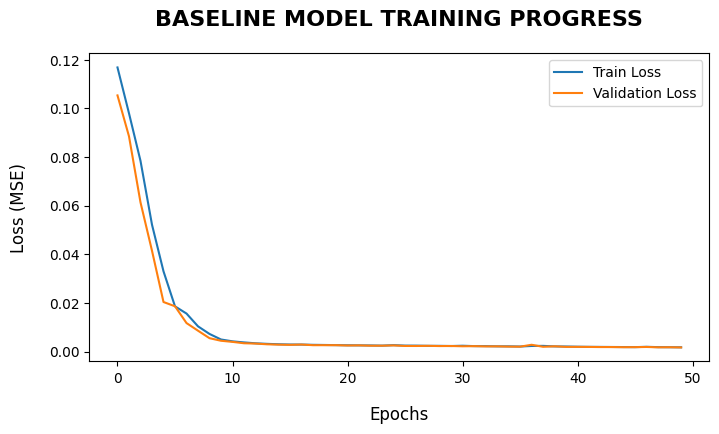



✅ BLOCK 7 COMPLETED: Baseline Model trained.


In [11]:
# ==========================================================================================================================================================
# BLOCK 7: TRAIN BASELINE AUTOENCODER
# ==========================================================================================================================================================
# Description: Executes the training loop using the training data as both input and target,
# and visualizes the learning curve (Loss vs. Epochs)
# ==========================================================================================================================================================

print("INITIATING BASELINE MODEL TRAINING PHASE...\n")
print("Action: Executing unsupervised learning loop (50 Epochs).\n")
print()

print("Starting Baseline Training...\n")


# TRAINING EXECUTION
# Train the model using fixed hyperparameters (no tuning yet)
# Use training images as both input and target because this is unsupervised learning
history = autoencoder.fit(
    train_images, train_images, 
    epochs=50,                  
    batch_size=32,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

print("\n")


# TRAINING VISUALIZATION
# Plot Training vs Validation Loss to check for overfitting or convergence
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('BASELINE MODEL TRAINING PROGRESS', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Epochs', fontsize=12, labelpad=15)
plt.ylabel('Loss (MSE)', fontsize=12, labelpad=15)
plt.legend()
plt.show()


# FINAL VERIFICATION
print("\n\n✅ BLOCK 7 COMPLETED: Baseline Model trained.")

### BLOCK 8: EVALUATION, HEATMAPS & ROC CURVE

**OBJECTIVE:**
This concluding block executes the **Inference & Evaluation Phase**. We deploy the trained Autoencoder on the Test Set to quantify its ability to distinguish between healthy and defective samples. Crucially, we benchmark its performance against the Classical SVM model (from Block 5) to determine if Deep Learning offers a tangible advantage.

**EVALUATION METRICS:**
1.  **Anomaly Scoring (MSE):**
    * For every test image, we calculate the **Mean Squared Error** between the input and the model's reconstruction.
    * **Logic:** A *low* MSE implies the image is "Normal" (familiar to the model). A *high* MSE implies an "Anomaly" (the model failed to reconstruct it).<br><br>
    
2.  **ROC Analysis (AUC Score):**
    * We plot the **Receiver Operating Characteristic (ROC)** curve.
    * **AUC Comparison:** We calculate the Area Under the Curve to provide a direct numerical comparison with the SVM. A higher AUC indicates superior separation capabilities.

**VISUALIZATION STRATEGY (LOCALIZATION):**
To move beyond simple "Pass/Fail" classification, we generate **Error Heatmaps** for qualitative analysis:
1.  **Method:** We compute the pixel-wise absolute difference: $|Input - Output|$.
2.  **The Heatmap:**<br><br>
    * **Blue/Cool Areas:** Low error (Successful reconstruction $\rightarrow$ Normal region).
    * **Red/Jet Areas:** High error (Reconstruction failure $\rightarrow$ **Defect Location**).
    * **Significance:** This visualization proves that the model identifies *exactly where* the defect (scratch, contamination) is located, providing interpretable results.

INITIATING BASELINE MODEL EVALUATION PHASE...

Action: AUC Calculation, ROC Curve Analysis & Defect Localization.

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step


DEEP LEARNING (BASELINE) RESULT -> AUC SCORE: 0.57




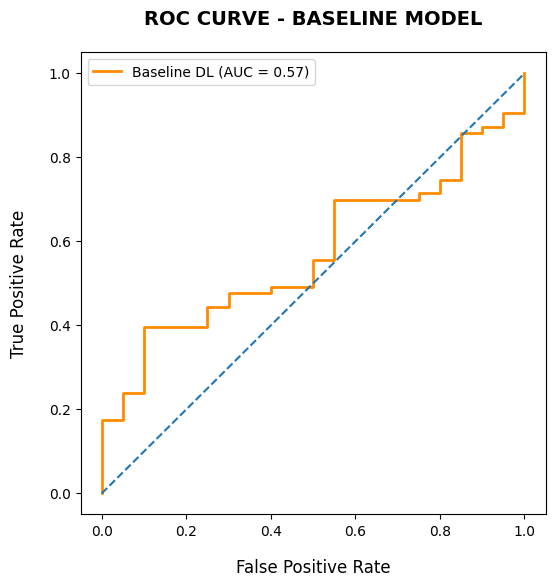



Visualizing Defect Localization (Heatmaps)...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


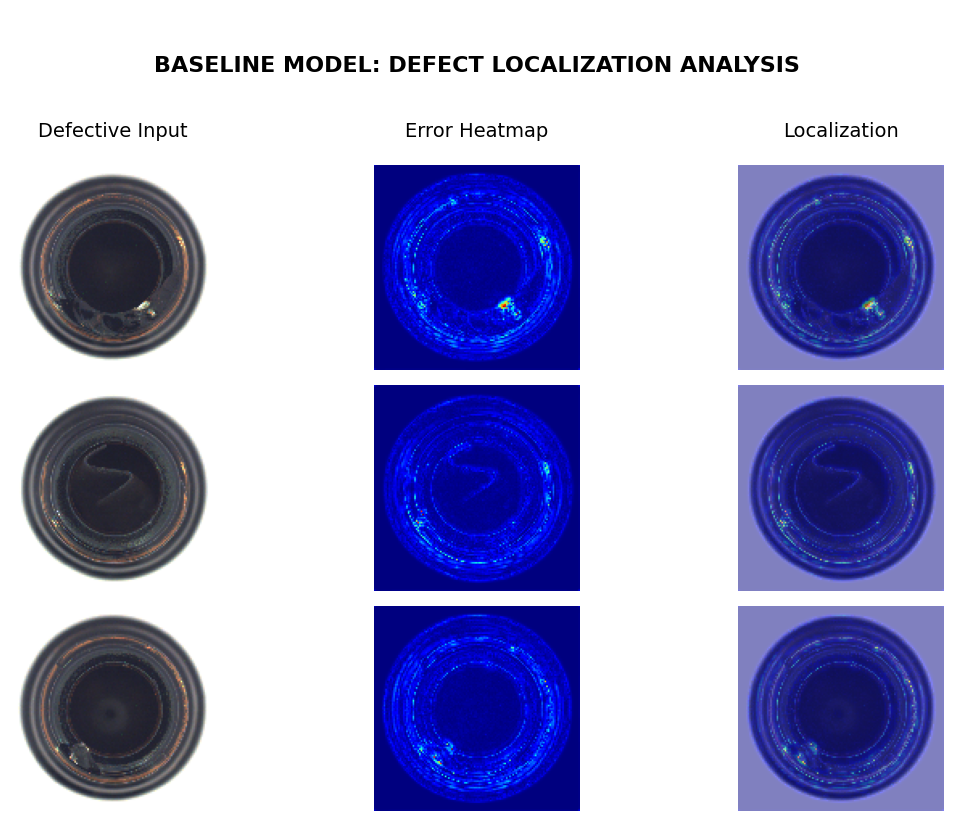



✅ BLOCK 8 COMPLETED: Evaluation done.


In [12]:
# ==========================================================================================================================================================
# BLOCK 8: EVALUATION, HEATMAPS AND ROC CURVE
# ==========================================================================================================================================================
# Description: Generates predictions, calculates the AUC score, plots the ROC curve,
# and visualizes defect localization using error heatmaps
# ==========================================================================================================================================================

print("INITIATING BASELINE MODEL EVALUATION PHASE...\n")
print("Action: AUC Calculation, ROC Curve Analysis & Defect Localization.")
print()


# 1. PREDICTION & ERROR CALCULATION
# Generate reconstructions for the full test set
x_test_full = np.concatenate((test_good, test_bad))
reconstructions = autoencoder.predict(x_test_full)

# Calculate MSE (Reconstruction Error) for each image
# Higher MSE indicates a higher probability of anomaly
mse_scores = np.mean(np.square(x_test_full - reconstructions), axis=(1, 2, 3))


# 2. QUANTITATIVE EVALUATION (AUC SCORE)
# Calculate AUC Score
auc_dl = roc_auc_score(y_test_labels, mse_scores)
print(f"\n\nDEEP LEARNING (BASELINE) RESULT -> AUC SCORE: {auc_dl:.2f}\n\n")


# 3. ROC CURVE VISUALIZATION
fpr, tpr, _ = roc_curve(y_test_labels, mse_scores)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Baseline DL (AUC = {auc_dl:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC CURVE - BASELINE MODEL', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('False Positive Rate', fontsize=12, labelpad=15)
plt.ylabel('True Positive Rate', fontsize=12, labelpad=15)

plt.legend()
plt.show()


# 4. QUALITATIVE EVALUATION (HEATMAPS)
# Define helper function for visual defect localization
def plot_heatmap(original, reconstructed):

    """
    Generates a normalized error heatmap between the original and reconstructed images.

    Args:
        original (numpy.ndarray): The original input image.
        reconstructed (numpy.ndarray): The output from the autoencoder.

    Returns:
        numpy.ndarray: A 2D heatmap array normalized to range [0, 1].
    """

    error = np.abs(original - reconstructed)
    # Average across channels to get a single intensity map
    error_mean = np.mean(error, axis=-1)
    
    # Normalize heatmap to [0, 1] for display purposes
    heatmap = (error_mean - error_mean.min()) / (error_mean.max() - error_mean.min())
    return heatmap


print("\n\nVisualizing Defect Localization (Heatmaps)...\n")
n_show = 3
indices = np.random.randint(0, len(test_bad), n_show)

plt.figure(figsize=(12, 8))
plt.suptitle("\n\nBASELINE MODEL: DEFECT LOCALIZATION ANALYSIS", fontsize=16, fontweight='bold', y=1.02)

for i, idx in enumerate(indices):
    orig = test_bad[idx]
    # Predict strictly on a single sample (expand_dims needed for batch dimension)
    recon = autoencoder.predict(np.expand_dims(orig, axis=0))[0]
    heatmap = plot_heatmap(orig, recon)

    # PLOT ORIGINAL
    plt.subplot(n_show, 3, i*3 + 1)
    plt.imshow(orig)
    if i == 0: 
        plt.title("Defective Input", fontsize=14, pad=20)
    plt.axis('off')
    
    # PLOT HEATMAP
    plt.subplot(n_show, 3, i*3 + 2)
    plt.imshow(heatmap, cmap='jet')
    if i == 0: 
        plt.title("Error Heatmap", fontsize=14, pad=20)
    plt.axis('off')
    
    # PLOT OVERLAY
    plt.subplot(n_show, 3, i*3 + 3)
    plt.imshow(orig)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    if i == 0: 
        plt.title("Localization", fontsize=14, pad=20)
    plt.axis('off')
    
plt.tight_layout()
plt.show()


# FINAL VERIFICATION
print("\n\n✅ BLOCK 8 COMPLETED: Evaluation done.")

### BLOCK 9: FINAL MODEL COMPARISON (SVM vs BASELINE DL)

**OBJECTIVE:**
This final block synthesizes the findings of Notebook 1. Having trained both the Classical Machine Learning model (One-Class SVM) and the Deep Learning Baseline (Simple Autoencoder), we now perform a direct **Comparative Performance Evaluation**. The goal is to visually quantify the "Performance Gap" between traditional statistical methods and neural networks.

**VISUALIZATION STRATEGY:**
We utilize a **Comparative Bar Chart** to display the AUC Scores side-by-side:
* **Metric:** Area Under the Curve (AUC). A higher bar indicates a superior ability to distinguish between "Good" and "Defective" products.
* **Color Coding:**<br><br>
    * **Grey (SVM):** Represents the "Control" or legacy method.
    * **Orange (Autoencoder):** Represents the "Experimental" Deep Learning method.

**THESIS MILESTONE:**
This chart serves as the **Baseline Conclusion**.
* If the Autoencoder surpasses the SVM, it validates the hypothesis that Deep Learning is better suited for high-dimensional image data.
* The resulting score establishes the "floor" of our performance. In the subsequent notebooks (Notebook 2 & 4), our objective will be to optimize architectures and use Transfer Learning to significantly raise this "ceiling."

INITIATING FINAL PERFORMANCE COMPARISON...

Action: Benchmarking Classical ML (SVM) vs. Baseline Deep Learning (Autoencoder).




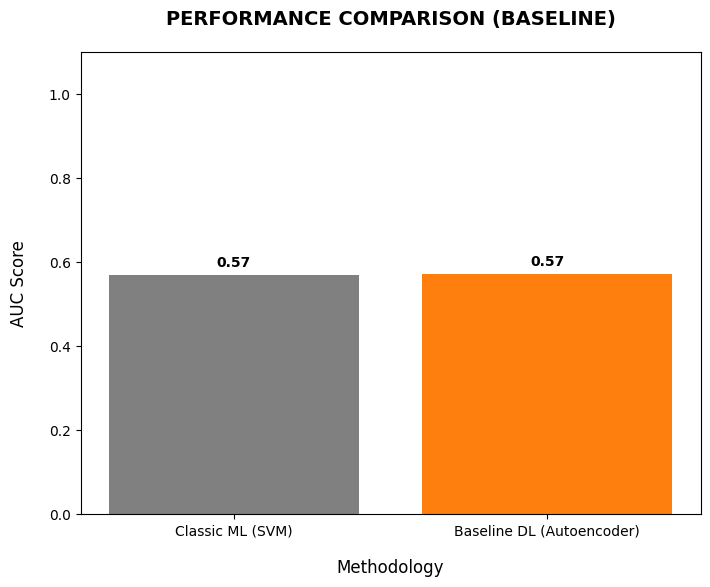



✅ BLOCK 9 COMPLETED: BASELINE NOTEBOOK COMPLETED.


In [13]:
# ==========================================================================================================================================================
# BLOCK 9: FINAL MODEL COMPARISON (SVM vs BASELINE DL)
# ==========================================================================================================================================================
# Description: Visualizes the performance gap between Classical ML and the Baseline Autoencoder
# using a side-by-side bar chart comparison of their AUC scores
# ==========================================================================================================================================================

print("INITIATING FINAL PERFORMANCE COMPARISON...\n")
print("Action: Benchmarking Classical ML (SVM) vs. Baseline Deep Learning (Autoencoder).\n")
print()


# DATA PREPARATION
# Define models and scores for the bar chart comparison
models = ['Classic ML (SVM)', 'Baseline DL (Autoencoder)']
scores = [auc_svm, auc_dl]


# VISUALIZATION (BAR CHART)
plt.figure(figsize=(8, 6))
bars = plt.bar(models, scores, color=['grey', '#ff7f0e'])
plt.ylabel('AUC Score')
plt.title('PERFORMANCE COMPARISON (BASELINE)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Methodology', fontsize=12, labelpad=15)
plt.ylabel('AUC Score', fontsize=12, labelpad=15)
# Limit set to 1.1 to leave space for labels
plt.ylim(0, 1.1)

# ANNOTATION
# Add numerical labels on top of the bars for precise reading
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', fontweight='bold')

plt.show()


# FINAL VERIFICATION
print("\n\n✅ BLOCK 9 COMPLETED: BASELINE NOTEBOOK COMPLETED.")